In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace

In [2]:
image = cv2.imread('dog.jpg', cv2.IMREAD_GRAYSCALE)

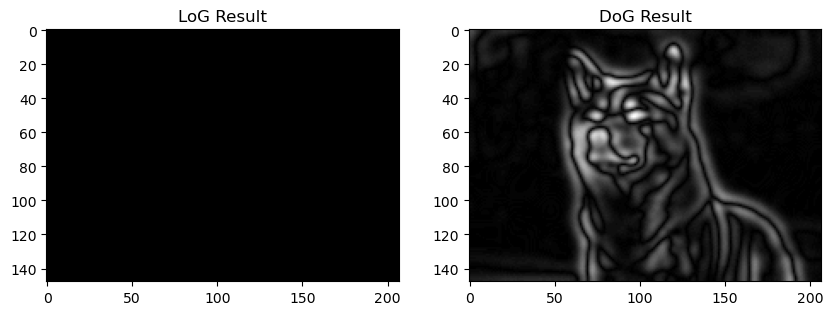

In [3]:
# LoG (Laplacian of Gaussian)
def laplacian_of_gaussian(image, sigma):
    log_image = gaussian_laplace(image, sigma=sigma)
    return (log_image < -0.03).astype(np.uint8) * 255  # Threshold tuning

log_result = laplacian_of_gaussian(image, sigma=2.0)

# DoG (Difference of Gaussian)
def difference_of_gaussian(image, sigma1, sigma2):
    blur1 = cv2.GaussianBlur(image, (0, 0), sigma1)
    blur2 = cv2.GaussianBlur(image, (0, 0), sigma2)
    return cv2.absdiff(blur1, blur2)

dog_result = difference_of_gaussian(image, sigma1=2.0, sigma2=4.0)

# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('LoG Result')
plt.imshow(log_result, cmap='gray')
plt.subplot(1, 2, 2)
plt.title('DoG Result')
plt.imshow(dog_result, cmap='gray')
plt.show()

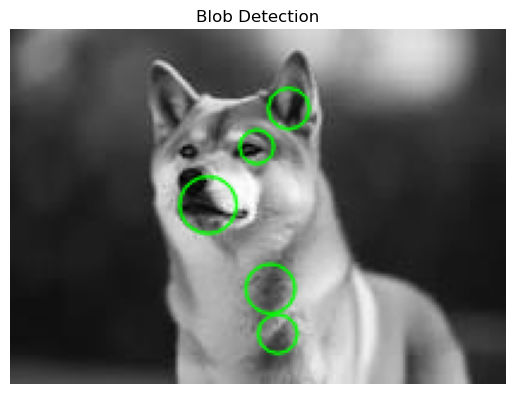

In [4]:



params = cv2.SimpleBlobDetector_Params()
params.filterByArea = True
params.minArea = 100
params.maxArea = 10000
params.filterByCircularity = False
params.filterByConvexity = False
params.filterByInertia = False

#detector
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(image)


result_image = cv2.drawKeypoints(image, keypoints, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert BGR to RGB for displaying with matplotlib
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

# Show the result
plt.imshow(result_image_rgb)
plt.title('Blob Detection')
plt.axis('off')
plt.show()


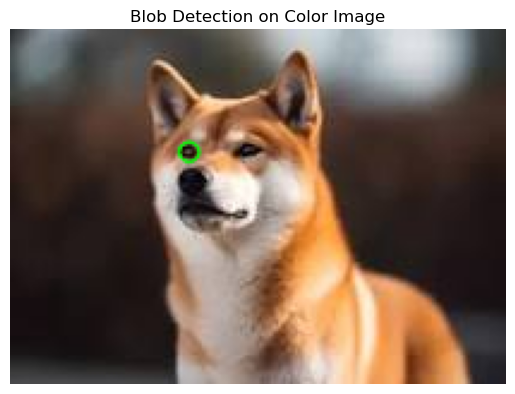

In [9]:


# Load color image
image = cv2.imread('dog.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blob detection using SimpleBlobDetector
params = cv2.SimpleBlobDetector_Params()
params.minThreshold = 50
params.maxThreshold = 200

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray_image)

# Draw blobs on original color image
result_image = cv2.drawKeypoints(image, keypoints, None, (0, 255, 0), cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert BGR to RGB for displaying with matplotlib
result_image_rgb = cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB)

# Show the result
plt.imshow(result_image_rgb)
plt.title('Blob Detection on Color Image')
plt.axis('off')
plt.show()


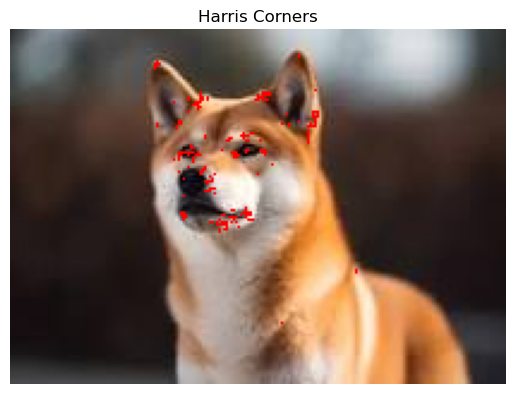

In [10]:


# Load image
image = cv2.imread('dog.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Harris Corner Detection
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Mark corners on image
image[dst > 0.01 * dst.max()] = [0, 0, 255]

# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show the result
plt.imshow(image_rgb)
plt.title('Harris Corners')
plt.axis('off')
plt.show()


C:\Users\daksh\AppData\Local\Temp\ipykernel_8916\963117909.py:7: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


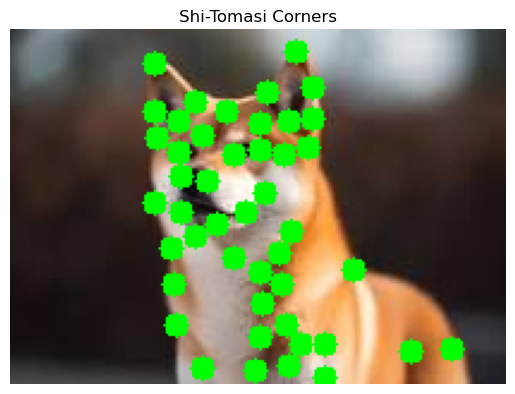

In [11]:

# Load image
image = cv2.imread('dog.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Shi-Tomasi corner detection
corners = cv2.goodFeaturesToTrack(gray, maxCorners=100, qualityLevel=0.01, minDistance=10)
corners = np.int0(corners)

# Draw corners on image
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(image, (x, y), 5, (0, 255, 0), -1)

# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show the result
plt.imshow(image_rgb)
plt.title('Shi-Tomasi Corners')
plt.axis('off')
plt.show()
